In [10]:
# Week 4 Preview: Deep Learning Basics
# Notes: Neural networks use layers (input, hidden, output). ReLU activation for hidden layers. Adam optimizer for backpropagation.
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Load housing data (same as Week 3)
df = pd.read_csv('house_prices.csv')
df = df[df['price'].notna() & (df['price'] > 0)]
df.fillna({
    'bedrooms': df['bedrooms'].mode()[0],
    'bathrooms': df['bathrooms'].mode()[0],
    'sqft_living': df['sqft_living'].mean(),
    'sqft_lot': df['sqft_lot'].mean(),
    'sqft_above': df['sqft_above'].mean()
}, inplace=True)
df = df[df['price'] < df['price'].quantile(0.99)]


In [11]:

# Features and target
features = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']
X = df[features]
y = df['price']



In [12]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [13]:
# Define neural network
keras_model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(len(features),)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)  # Regression output for price
])
keras_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
keras_model.summary()

# Train neural network
history = keras_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)


D:\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 375341088768.0000 - mae: 535172.0000 - val_loss: 350624022528.0000 - val_mae: 521453.1250
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 375305043968.0000 - mae: 535145.0000 - val_loss: 350556684288.0000 - val_mae: 521402.5625
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 375171678208.0000 - mae: 535047.6875 - val_loss: 350361878528.0000 - val_mae: 521256.7500
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 374855794688.0000 - mae: 534818.5000 - val_loss: 349955915776.0000 - val_mae: 520954.2188
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 374284550144.0000 - mae: 534396.0000 - val_loss: 349273882624.0000 - val_mae: 520445.2500
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 373379268608.0000 - mae: 533740.2500 - val_loss: 348250865664.0000 - val_mae: 519681.0000
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 372099842048.0000 - mae: 532785.6875 - val_loss: 34684

In [14]:
# Evaluate

keras_y_pred_nn = keras_model.predict(X_test)
nn_mse = mean_squared_error(y_test,keras_y_pred_nn)
nn_rmse = np.sqrt(nn_mse)
nn_r2 = r2_score(y_test, keras_y_pred_nn)
print(f"Neural Network - MSE: {nn_mse:.2f}, RMSE: {nn_rmse:.2f}, R²: {nn_r2:.2f}")



26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Neural Network - MSE: 94389583048.52, RMSE: 307228.88, R²: -0.15


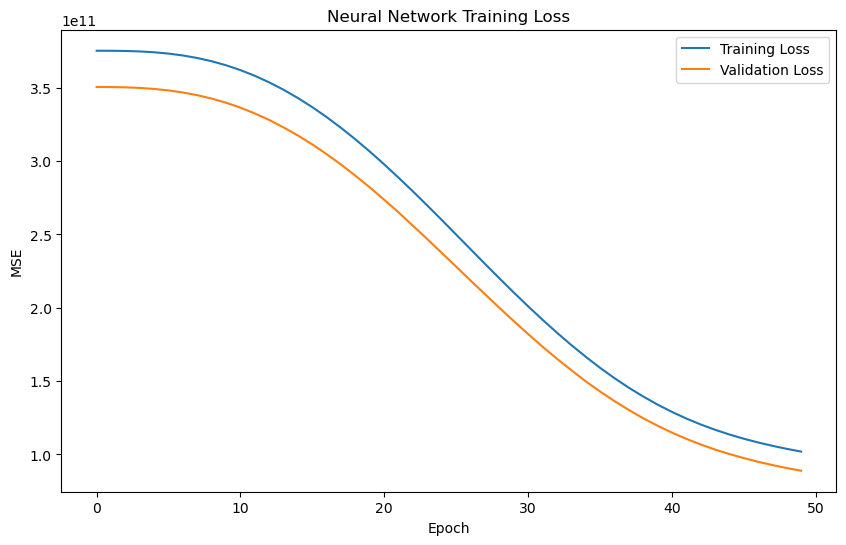

In [15]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4')
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e')
plt.title('Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.savefig('nn_training_loss.png')
plt.show()